In [3]:
import json

In [4]:
import json
import urllib.request

url = "https://raw.githubusercontent.com/kedarwent/ML-colour-combinations-dictionary-of-colour/master/colors.json"

with urllib.request.urlopen(url) as response:
    data = json.load(response)

In [5]:
data[0] # example value in json file

{'name': 'Hermosa Pink',
 'combinations': [176, 227, 273],
 'swatch': 0,
 'cmyk': [0, 30, 6, 0],
 'lab': [83.42717631799802, 22.136186770428026, 1.6381322957198563],
 'rgb': [249, 193, 206],
 'hex': '#f9c1ce'}

In [6]:
combos_no_duplicates = list(set([j for i in data for j in i['combinations']])) # list of colour combinations
len(combos_no_duplicates) # number of colour combinations

348

In [7]:
number = 0
for i in data:
    i['number'] = number
    number += 1

In [8]:
data[0]

{'name': 'Hermosa Pink',
 'combinations': [176, 227, 273],
 'swatch': 0,
 'cmyk': [0, 30, 6, 0],
 'lab': [83.42717631799802, 22.136186770428026, 1.6381322957198563],
 'rgb': [249, 193, 206],
 'hex': '#f9c1ce',
 'number': 0}

In [9]:
max(i['number'] for i in data) # number of colours in dataset

158

In [10]:
import pandas as pd

combo_names = dict()

for colour in data:
    for combo in colour['combinations']:
        if combo in combo_names:
            combo_names[combo].append(colour['number'])
        else:
            combo_names[combo] = [colour['number']]

In [11]:
combo_names[1]

[65, 117]

In [18]:
colours_df = pd.DataFrame(data)

colours_df[:5]

,name,combinations,swatch,cmyk,lab,rgb,hex,number
0,Hermosa Pink,"[176, 227, 273]",0,"[0, 30, 6, 0]","[83.42717631799802, 22.136186770428026, 1.6381...","[249, 193, 206]",#f9c1ce,0
1,Corinthian Pink,"[27, 43, 87, 97, 128, 169, 174, 206, 246, 254,...",0,"[0, 35, 15, 0]","[80.34637979705501, 25.369649805447466, 7.8793...","[248, 182, 186]",#f8b6ba,1
2,Cameo Pink,"[101, 105, 116, 120, 165, 231]",0,"[10, 32, 19, 0]","[77.21675440604257, 17.198443579766547, 4.9494...","[224, 179, 182]",#e0b3b6,2
3,Fawn,"[18, 125, 308]",0,"[18, 31, 30, 0]","[74.48996719310291, 11.194552529182886, 9.3852...","[209, 176, 167]",#d1b0a7,3
4,Light Brown Drab,"[35, 68, 185, 191, 223, 239, 244, 268, 285, 321]",0,"[8, 30, 20, 25]","[64.1168841077287, 13.023346303501938, 5.34241...","[181, 147, 146]",#b59392,4


In [59]:
def convert_to_dataframes(num, combo_names, colours_df):

    # getting df of all combos of a certain length
    num_colours = {
        k: v
        for k, v in combo_names.items()
        if len(v) == num
    }

    #putting these combos into a df
    num_df = pd.DataFrame(num_colours).T
    #renaming for readability
    num_df.columns = [f'colour_{i}'for i in range(1, num+1)]

    # merging with colours_df to get details of colours within combo
    for i in range(1, num+1): 
        num_df = num_df.merge(
        colours_df[['number','lab', 'name']]
        , how='left'
        , left_on=f'colour_{i}'
        , right_on='number').drop('number', axis=1)

        # renaming so it's clear which details are for which colour
        col_dict = {'lab': f'lab_{i}', 'name': f'name_{i}'} 
        num_df.columns = [col_dict.get(x, x) for x in num_df.columns]

        # splitting LAB values into separate columns
        num_df[[f'l_{i}', f'a_{i}', f'b_{i}']] = pd.DataFrame(num_df[f'lab_{i}'].tolist(), index= num_df.index)

    for i in range(1, num+1): 
        # comparing LAB values across all pairs in a combo
        # making j after i to avoid repeating comparisons, e.g. l_1 vs l_2, and l_2 vs l_1
        for j in range(i+1, num+1):
            for ax in ['l', 'a', 'b']:
                num_df[f'{ax}_{i}_{j}'] = abs(num_df[f'{ax}_{i}'] - num_df[f'{ax}_{j}'])

    return num_df
        





In [60]:
two_df = convert_to_dataframes(2, combo_names, colours_df)

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='b_1_2', ylabel='Count'>

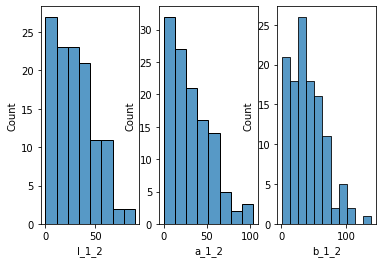

In [66]:
fig, ax = plt.subplots(1,3, sharex=False, sharey=False)

sns.histplot(two_df, x='l_1_2', ax=ax[0])
sns.histplot(two_df, x='a_1_2', ax=ax[1])
sns.histplot(two_df, x='b_1_2', ax=ax[2])

In [67]:
for ax in ['l', 'a', 'b']:
    two_df[f'max_{ax}'] = two_df[[f'{ax}_1', f'{ax}_2']].max(axis=1)

<Axes: xlabel='max_b', ylabel='b_1_2'>

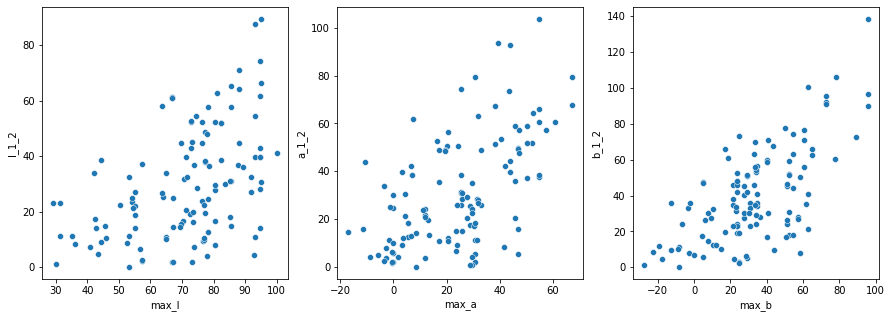

In [74]:
fig, ax = plt.subplots(1,3, sharex=False, sharey=False, figsize=(15,5))

sns.scatterplot(two_df, x='max_l', y='l_1_2', ax=ax[0])
sns.scatterplot(two_df, x='max_a', y='a_1_2', ax=ax[1])
sns.scatterplot(two_df, x='max_b', y='b_1_2', ax=ax[2])

<Axes: xlabel='a_1_2', ylabel='b_1_2'>

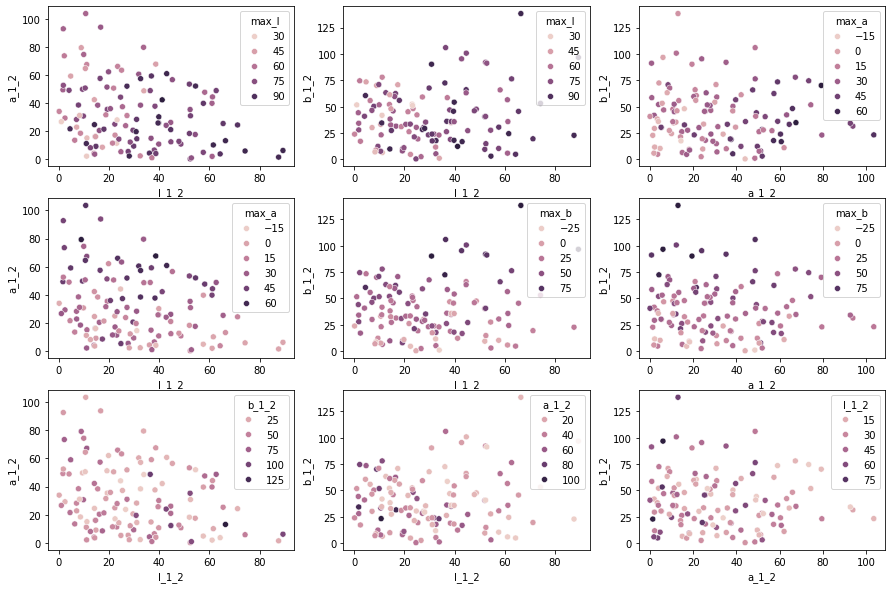

In [89]:
fig, ax = plt.subplots(3,3, sharex=False, sharey=False, figsize=(15,10))

# comparing 2 LAB-axes and the max of x-axis LAB-axis
sns.scatterplot(two_df, x='l_1_2', y='a_1_2', hue='max_l', ax=ax[0,0])
sns.scatterplot(two_df, x='l_1_2', y='b_1_2', hue='max_l', ax=ax[0,1])
sns.scatterplot(two_df, x='a_1_2', y='b_1_2', hue='max_a', ax=ax[0,2])
# comparing 2 LAB-axes and the max of y-axis LAB-axis
sns.scatterplot(two_df, x='l_1_2', y='a_1_2', hue='max_a', ax=ax[1,0])
sns.scatterplot(two_df, x='l_1_2', y='b_1_2', hue='max_b', ax=ax[1,1])
sns.scatterplot(two_df, x='a_1_2', y='b_1_2', hue='max_b', ax=ax[1,2])
# comparing 2 LAB-axes and the third LAB-axis as hue
sns.scatterplot(two_df, x='l_1_2', y='a_1_2', hue='b_1_2', ax=ax[2,0])
sns.scatterplot(two_df, x='l_1_2', y='b_1_2', hue='a_1_2', ax=ax[2,1])
sns.scatterplot(two_df, x='a_1_2', y='b_1_2', hue='l_1_2', ax=ax[2,2])

In [ ]:
# need to add hue and chroma for each colour, to compare between colours in combinations!